<a href="https://colab.research.google.com/github/freeteck-python/Sentiment-Analysis-of-Cafe-Reviews-/blob/main/%D0%90%D0%94_6_%D0%BF_13_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv('cafe_reviews.csv')
print(data)
print(data.columns)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


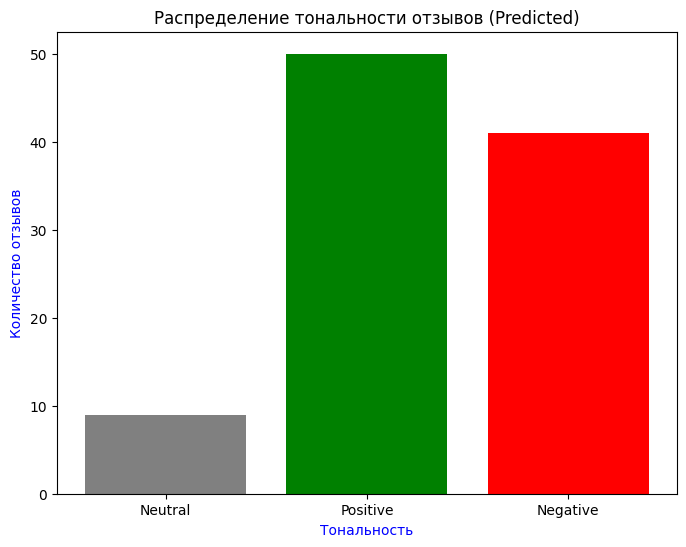

In [3]:
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
import pandas as pd
import matplotlib.pyplot as plt

# Читаем наш файл
data = pd.read_csv('cafe_reviews.csv')
# Инициализируем токенайзер и модель
tokenizer = AutoTokenizer.from_pretrained('blanchefort/rubert-base-cased-sentiment')
model = AutoModelForSequenceClassification.from_pretrained('blanchefort/rubert-base-cased-sentiment')

# Функция анализа тональности
def analyze_sentiment(text):
    inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt')
    outputs = model(**inputs)

    # формат [0] = Neutral, [1] = Positive, [2] = Negative
    predicted_class = torch.argmax(outputs.logits, dim=1).item()
    return predicted_class

# Сохраняем результат применения функции к столбцу 'text' в новый столбец 'predicted_sentiment'
data['predicted_sentiment'] = data['text'].apply(analyze_sentiment)

# Визуализация
sentiments_counts = data['predicted_sentiment'].value_counts().sort_index()
labels = {0: 'Neutral', 1: 'Positive', 2: 'Negative'}
display_labels = [labels[i] for i in sentiments_counts.index]

plt.figure(figsize=(8, 6))
plt.bar(display_labels, sentiments_counts.values, color=['gray', 'green', 'red'])

plt.xlabel('Тональность', color='blue')
plt.ylabel('Количество отзывов', color='blue')
plt.title('Распределение тональности отзывов (Predicted)')
plt.savefig('sentiment_distribution.png') # отображение диаграммы в репозитории
plt.show()


